**Importing Necessary Liabraries :-**

In [1]:
# Import Liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

**Connecting Python to PostgreSQL :-**

In [2]:
user = 'postgres'
password = '636301'
host = 'localhost'
port = 5432
database = 'Customer_Churn_db'
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')

**Loading Excel Data to PostgreSQL :-**

In [3]:
# xls = pd.ExcelFile(r"D:\\VS Code\\Churn Analysis\\Complete project file\\Churn_Raw_Dataset.xlsx")

# for sheet_name in xls.sheet_names:
#     df = pd.read_excel(xls, sheet_name=sheet_name)
#     df.to_sql(sheet_name, engine, if_exists="replace", index=False)
#     print(f"Loaded {sheet_name}: {len(df)} rows")

**Importing Data in python from PostgreSQL :-**

In [4]:
sql_query = """
SELECT table_name
FROM information_schema.tables
where table_schema = 'public'
"""

tables = pd.read_sql_query(sql_query, engine)

for table_name in tables['table_name']:
    df = pd.read_sql(f"SELECT * FROM \"{table_name}\"", engine)
    globals()[f"df_{table_name}"] = df
    print(f"Data from table 'df_{table_name}':")

Data from table 'df_db_customer':
Data from table 'df_db_subscription':
Data from table 'df_db_support':


In [5]:
df_db_customer = df_db_customer

df_db_subscription = df_db_subscription

df_db_support = df_db_support

### Customer Table 🟢⏩

**Data Overview in Table 1 (Customer Table) :-**

In [6]:
df_db_customer.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='object')

In [7]:
# Checking Top 5 rows of the dataset
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,2038-IDQFY,pallavi,India,Telangana,Women,07/25/1994,reading,None
1,6407-DITBC,vivek,India,Delhi,Male,1968-05-20,movie,None
2,0736-TAGXO,vijay,India,Bihar,Female,03-12-1985,None,None
3,5779-HZHQJ,rangadevi,India,Maharashtra,M,2004-01-08 00:00:00,None,None
4,4610-QVPTR,vishakha,India,Bihar,Female,18 Sep 1960,None,None


In [8]:
# Checking Bottom 5 rows of the dataset
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
101016,1011-VAJTM,deepak,INDIA,Assam,Female,None,sports,None
101017,6085-OWTSG,shiva,India,Uttar Pradesh,Male,2006-03-26 00:00:00,None,None
101018,0346-CEGQY,naveen,None,Nagaland,Male,05-09-1955,None,None
101019,6913-YYYNP,Chitra,India,Maharashtra,Male,08/25/1958,None,None
101020,5856-CALTC,meena,India,Assam,Female,1993-01-24 00:00:00,None,None


In [9]:
# Checking 10 Random 10 Rows  of the dataset
df_db_customer.sample(10)

,customerid,name,country,state,gender,dob,interests,pincode
22652,3809-RTXCH,Kiran,India,Maharashtra,male,04/01/1955,drama,None
53228,1696-OIIOO,MADAN,India,Punjab,Female,23-01-1996,music,None
32277,1353-PUGRS,madan,Bharat,Gujarat,Male,1965-05-09 00:00:00,fitness,None
77805,6054-VEARF,lata,nepal,Lumbini,Men,2002-03-19,fashion,None
78789,3356-ZDVYW,shweta,India,Karnataka,Female,18-05-1988,None,None
1347,5608-RSUSR,asha,IND,Delhi,Male,None,None,IN-582315
38388,3207-JTTTO,shweta,India,Punjab,male,23-02-1987,movie,None
77613,7151-WFOMA,vivek,nepal,Sudurpashchim,female,05 May 1986,fashion,None
50364,1528-HQDRV,Raju,India,Jharkhand,Female,1959-09-27 00:00:00,None,None
41452,2064-JYWNH,None,India,Maharashtra,Women,19-11-1997,None,None


In [10]:
# Checking the shape of the dataset (Number of rows and columns)
print('Total Rows in Customer Table :',df_db_customer.shape[0])
print('Total Columns in Customer Table :',df_db_customer.shape[1])

Total Rows in Customer Table : 101021
Total Columns in Customer Table : 8


In [11]:
# Getting information about our dataset like total rows,
# columns,datatypes of each column and memory requirement.
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101021 entries, 0 to 101020
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   customerid  101021 non-null  object
 1   name        98098 non-null   object
 2   country     93091 non-null   object
 3   state       100164 non-null  object
 4   gender      93114 non-null   object
 5   dob         97055 non-null   object
 6   interests   38897 non-null   object
 7   pincode     4052 non-null    object
dtypes: object(8)
memory usage: 6.2+ MB


In [12]:
# Checking % for missing dataset in each column
df_db_customer.isnull().mean()*100

customerid     0.000000
name           2.893458
country        7.849853
state          0.848338
gender         7.827085
dob            3.925916
interests     61.496125
pincode       95.988953
dtype: float64

In [13]:
# Checking not null values in each column
df_db_customer.notnull().sum()

customerid    101021
name           98098
country        93091
state         100164
gender         93114
dob            97055
interests      38897
pincode         4052
dtype: int64

In [14]:
# Checking total duplicated values available in the dataset.
duplicate_values=df_db_customer.duplicated().sum()
print('Total Duplicate Values :',duplicate_values)

Total Duplicate Values : 887


In [15]:
# Show duplicated values available in the dataset.
dup = df_db_customer[df_db_customer.duplicated(keep=False)]
dup.sort_values(by='customerid')

,customerid,name,country,state,gender,dob,interests,pincode
18758,0044-ATDPE,neha,India,Bihar,Male,09-10-1955,None,None
7322,0044-ATDPE,neha,India,Bihar,Male,09-10-1955,None,None
9204,0058-LEOKL,amit,India,Uttar Pradesh,Female,1982-12-27,None,None
43309,0058-LEOKL,amit,India,Uttar Pradesh,Female,1982-12-27,None,None
75277,0064-YACDC,arjun,India,Jharkhand,Female,01/05/2002,None,None
...,...,...,...,...,...,...,...,...
97928,9985-MKJMP,ajay,India,Rajasthan,Female,1958-02-02,None,None
64993,9991-PUSQV,RIKIM,India,Tamil Nadu,Female,15-11-1963,None,None
48937,9991-PUSQV,RIKIM,India,Tamil Nadu,Female,15-11-1963,None,None
86098,9996-XDLKR,rajesh,None,Odisha,Female,16-11-1988,movie,None


In [16]:
# How to drop the duplicate value?
# First we need to create a copy of dataset.
df_db_customer1=df_db_customer.copy()

**Data Cleaning in Table 1 (Customer Table) :-**

In [17]:
# What to fix in Customer Table
# 1)- Drop Unnecessary Columns : interests and pincode (61 and 96% of data is missing)
# 2)- Remove Duplicate Values : 1000 Rows
# 3)- Rename Column Name : From name to customername
# 4)- Change Data Type and Fix Formatting in DOB Column : Single Format for all dates
# 5)- Data Standardization and fix formatting in Gender Column : Proper Format Required
# 6)- Fix Formatting for Country Column : India/IND/india/INDIA/Bharat
# 7)- Fix Formatting for Name Column : Proper Format Required
# 8)- Find Age from DOB column : To check if impossible ages are present.
# 9)- Inconsistent State Spellings and Fix Formatting for State Column : 'Telengana' vs 'Telangana', 'Punjaab' vs 'Punjab', 'Keral' vs 'Kerala', 'wb' vs 'West Bengal'
# 10)- Handling Null values : Name, Country, State, Gender, DOB

In [18]:
# 1)- Drop Unnecessary Columns : interests and pincode (61 and 96% of data is missing)
df_db_customer.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='object')

In [19]:
df_db_customer = df_db_customer.drop(columns=['interests', 'pincode'])

print(df_db_customer.shape)

(101021, 6)


In [20]:
# 2)- Remove Duplicate Values : 1000 Rows
df_db_customer = df_db_customer.drop_duplicates(subset='customerid', keep='last')
print(df_db_customer.shape)

(100021, 6)


In [21]:
df_db_customer.duplicated().sum()

np.int64(0)

In [22]:
df_db_customer.notnull().sum()

customerid    100021
name           97123
country        92183
state          99169
gender         92185
dob            96094
dtype: int64

In [23]:
df_db_customer.isnull().sum()

customerid       0
name          2898
country       7838
state          852
gender        7836
dob           3927
dtype: int64

In [24]:
# 3)- Rename Column Name : From name to customername
df_db_customer = df_db_customer.rename(columns={'name':'customername'})
df_db_customer.head(2)

,customerid,customername,country,state,gender,dob
0,2038-IDQFY,pallavi,India,Telangana,Women,07/25/1994
1,6407-DITBC,vivek,India,Delhi,Male,1968-05-20


In [25]:
# 4)- Change Data Type : DOB Column
# Step 1: convert to real datetime first
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'],format='mixed', errors='coerce')
print(df_db_customer['dob'].dtype)
print(df_db_customer['dob'].isnull().sum())

datetime64[ns]
3927


In [26]:
# Step 2: now .dt works, format it
df_db_customer['dob'] = df_db_customer['dob'].dt.strftime('%d-%m-%Y')

In [27]:
print(df_db_customer['dob'].sample(10))

91640    01-05-1985
93089    05-03-1991
65570    20-03-1971
54633    12-01-1962
11909    17-12-1955
4902     07-07-2005
54291    22-08-1988
36801    22-04-1957
55531    18-03-1993
35470    11-02-1973
Name: dob, dtype: object


In [28]:
print(df_db_customer['dob'].dtype)

object


In [29]:
print(df_db_customer['dob'].isnull().sum())

3927


In [30]:
df_db_customer.notnull().sum()

customerid      100021
customername     97123
country          92183
state            99169
gender           92185
dob              96094
dtype: int64

In [31]:
# 5)- Data Standardization : Gender Column
# check current unique values first
print(df_db_customer['gender'].unique())

['Women' 'Male' 'Female' 'M' 'Men' 'F' None 'Other' 'male' 'female']


In [32]:
# clean whitespace and case first
df_db_customer['gender']=df_db_customer['gender'].str.strip().str.title()
print(df_db_customer['gender'].unique())

['Women' 'Male' 'Female' 'M' 'Men' 'F' None 'Other']


In [33]:
# map all variants to standard categories
gender_map = {
    'Male': 'Male',
    'Men': 'Male',
    'M': 'Male',
    'Female': 'Female',
    'Women': 'Female',
    'F': 'Female',
    'Other': 'Other',
    'Unknown': 'Unknown'
}

In [34]:
df_db_customer['gender'] = df_db_customer['gender'].map(gender_map)

In [35]:
print(df_db_customer['gender'].unique())

['Female' 'Male' nan 'Other']


In [36]:
# 6)- Fix Formatting for Country Column : India/IND/india/INDIA/Bharat
print(df_db_customer['country'].unique())

['India' 'IND' 'INDIA' ' India' 'Nepal' 'Bharat' None 'india' 'India '
 'nepal']


In [37]:
df_db_customer['country']=df_db_customer['country'].str.strip().str.title()
print(df_db_customer['country'].unique())

['India' 'Ind' 'Nepal' 'Bharat' None]


In [38]:
# map ind to india
india_map = {
    'Ind' : 'India',
    'India' : 'India',
    'Bharat' : 'India',
    'Unknown' : 'Unknown',
    'Nepal' : 'Nepal'
    }

In [39]:
df_db_customer['country'] = df_db_customer['country'].map(india_map)

In [40]:
print(df_db_customer['country'].unique())

['India' 'Nepal' nan]


In [41]:
# 7)- Fix Formatting for Name Column : Proper Format Required
df_db_customer.columns

Index(['customerid', 'customername', 'country', 'state', 'gender', 'dob'], dtype='object')

In [42]:
df_db_customer['customername']=df_db_customer['customername'].str.strip().str.title()

In [43]:
# 8)- Find Age from DOB column : To check if impossible ages are present.
print(df_db_customer['dob'].dtype)

object


In [44]:
# convert dob back to real datetime in temp variable.
dob_temp = pd.to_datetime(df_db_customer['dob'], format='%d-%m-%Y', errors='coerce')

In [45]:
# calculate age in years
df_db_customer['age'] = ((pd.Timestamp.now() - dob_temp).dt.days // 365)
print(df_db_customer['age'].describe())

count    96094.000000
mean        45.230941
std         15.005906
min         19.000000
25%         32.000000
50%         45.000000
75%         58.000000
max         71.000000
Name: age, dtype: float64


***Dateset looks like a totally realistic adult customer base. No negative ages, no 150-year-olds, nothing to flag or fix.***

In [46]:
# 9)- Inconsistent State Spellings : 'Telengana' vs 'Telangana', 'Punjaab' vs 'Punjab', 'Keral' vs 'Kerala', 'wb' vs 'West Bengal'
df_db_customer['state'].unique()

array(['Telangana', 'Delhi', 'Bihar', 'Maharashtra', 'Uttar Pradesh',
       'Odisha', 'Haryana', 'Madhya Pradesh', 'Jharkhand', 'Rajasthan',
       'Karnali', 'Nagaland', 'West Bengal', 'Tamil Nadu', 'Punjab',
       'Karnataka', 'wb', 'Assam', 'Kerala', None, 'Meghalaya',
       'maharashtra', ' Madhesh', 'Gujarat', 'Madhesh', 'Telengana',
       'Sudurpashchim', 'Kathmandu', 'uttar pradesh', 'Keral', 'Koshi',
       'Gandaki', 'Bagmati', ' Koshi', 'Lumbini', 'karnali', 'DELHI',
       ' Rajasthan', 'lumbini', 'karnataka ', 'madhesh', 'Punjaab',
       'koshi', 'gandaki', 'bagmati', 'sudurpashchim'], dtype=object)

In [47]:
df_db_customer['state']=df_db_customer['state'].str.strip().str.title()
df_db_customer['state'].unique()

array(['Telangana', 'Delhi', 'Bihar', 'Maharashtra', 'Uttar Pradesh',
       'Odisha', 'Haryana', 'Madhya Pradesh', 'Jharkhand', 'Rajasthan',
       'Karnali', 'Nagaland', 'West Bengal', 'Tamil Nadu', 'Punjab',
       'Karnataka', 'Wb', 'Assam', 'Kerala', None, 'Meghalaya', 'Madhesh',
       'Gujarat', 'Telengana', 'Sudurpashchim', 'Kathmandu', 'Keral',
       'Koshi', 'Gandaki', 'Bagmati', 'Lumbini', 'Punjaab'], dtype=object)

In [48]:
state_map={
    'Telengana' : 'Telangana',
    'Punjaab' : 'Punjab',
    'Wb' : 'West Bengal',
    'Keral' : 'Kerala'
}

In [49]:
df_db_customer['state']=df_db_customer['state'].replace(state_map)
df_db_customer['state'].unique()

array(['Telangana', 'Delhi', 'Bihar', 'Maharashtra', 'Uttar Pradesh',
       'Odisha', 'Haryana', 'Madhya Pradesh', 'Jharkhand', 'Rajasthan',
       'Karnali', 'Nagaland', 'West Bengal', 'Tamil Nadu', 'Punjab',
       'Karnataka', 'Assam', 'Kerala', None, 'Meghalaya', 'Madhesh',
       'Gujarat', 'Sudurpashchim', 'Kathmandu', 'Koshi', 'Gandaki',
       'Bagmati', 'Lumbini'], dtype=object)

In [50]:
# 10)- Handling Null values : Name, Country, State, Gender, DOB.
# Customer Name-Can't guess a person's name, so mark clearly as missing.
df_db_customer['customername']=df_db_customer['customername'].fillna('Unknown')

In [51]:
# Fill missing country based on state name.
df_db_customer['country'].value_counts()

country
India    84168
Nepal     8015
Name: count, dtype: int64

In [52]:
df_db_customer['country'].isnull().sum()

np.int64(7838)

In [53]:
india_states = ['Bihar', 'West Bengal', 'Rajasthan', 'Madhya Pradesh', 'Karnataka',
                 'Tamil Nadu', 'Kerala', 'Odisha', 'Meghalaya', 'Delhi', 'Telangana',
                 'Gujarat', 'Punjab', 'Nagaland', 'Haryana', 'Jharkhand',
                 'Maharashtra', 'Assam', 'Uttar Pradesh']

nepal_states = ['Kathmandu', 'Koshi', 'Madhesh', 'Bagmati', 'Gandaki',
                 'Lumbini', 'Karnali', 'Sudurpashchim']

In [54]:
def infer_country(state):
    if state in nepal_states:
        return 'Nepal'
    elif state in india_states:
        return 'India'
    return None  # state itself is missing or unrecognized

In [55]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].apply(infer_country))
print(df_db_customer['country'].isnull().sum())

56


In [56]:
print(df_db_customer['country'].unique())

['India' 'Nepal' None]


In [57]:
df_db_customer.isnull().sum()

customerid         0
customername       0
country           56
state            852
gender          7836
dob             3927
age             3927
dtype: int64

In [58]:
df_db_customer[df_db_customer['state'].isna()]

,customerid,customername,country,state,gender,dob,age
33,5261-VRXRO,Sunil,India,None,Male,09-12-1973,52.0
180,4629-TIQHQ,Chitra,India,None,Female,26-08-1971,55.0
210,8249-KZGWB,Anil,Nepal,None,Female,07-10-1968,58.0
299,0972-KGEOJ,Rahul,None,None,Male,15-03-1967,59.0
379,6652-XBMPG,Kiran,India,None,Male,19-05-1986,40.0
...,...,...,...,...,...,...,...
100134,6073-TMVEE,Dinesh,India,None,Male,10-11-1960,65.0
100735,7907-ZWSXG,Shweta,India,None,NaN,07-12-1990,35.0
100755,5498-THCJW,Kavita,India,None,Female,25-02-1995,31.0
100920,9021-CPFLI,Rekha,India,None,Male,13-02-1970,56.0


Country → State doesn't work because it's still one-to-many — knowing someone is in India still leaves 19 possible states to choose from (Bihar, Kerala, Punjab, etc. — all in your india_states list). There's no single "correct" state to fill in.

It would only work cleanly the other way (State → Country) because each state belongs to exactly one country — that's a many-to-one relationship, which is why it worked for filling country.

In [59]:
# Filling state with 'Unknown'.
df_db_customer['state']=df_db_customer['state'].fillna('Unknown')

In [60]:
# Filling country with 'Unknown' where state is also null.
df_db_customer['country']=df_db_customer['country'].fillna('Unknown')

In [61]:
# Filling gender with 'Unknown'
df_db_customer['gender'] = df_db_customer['gender'].fillna('Unknown')

**DOB (3,932 nulls)** → Leave it null, don't fill. 

There's no logical way to reconstruct it, and 
no "average" or "most common" DOB that would be meaningful. 

Filling it with a fake date would be worse than leaving it blank.

In [62]:
df_db_customer.isnull().sum()

customerid         0
customername       0
country            0
state              0
gender             0
dob             3927
age             3927
dtype: int64

In [63]:
df_db_customer.to_csv('D:\\VS Code\\Churn Analysis\\Complete project file\\Customer_Churn_Cleaned_Dataset.csv', index=False)

**Loading df_db_customer to PostgreSQL**

In [64]:
user = 'postgres'
password = '636301'
host = 'localhost'
port = 5432
database = 'Customer Churn Analysis'
engine2 = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')

In [65]:
df_db_customer.to_sql('customers', engine2, if_exists="replace", index=False)

21

**Data Overview in Table 2 (Subscription Table) :-**

In [66]:
# Checking Top 5 rows.
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,2101-JJWRN,02 Feb 2023,Refferal,02 Feb 2024,Standard,annual,NaT,None,7.99,1620.0,NaN
1,1272-UPHZN,01/16/2020,Paid,01/15/2021,Premium,Anual,2020-07-02,billing issue,22.99,674.0,86.0
2,5765-XWTPU,02/03/2020,Organic,02/02/2021,Basic,Monthly,NaT,None,16.99,1158.0,41.0
3,5282-HEYNF,09 Jun 2022,Paid,09 Jun 2023,Standard,Annual,NaT,None,16.99,1927.0,77.0
4,8034-HAPTL,2019-12-23,Organic,2023-12-22,Basic,Annual,NaT,None,20.99,2170.0,95.0


In [67]:
# Checking Bottom 5 rows.
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
95905,6970-LIXYE,11/14/2024,Paid,11/13/2028,Basic,Monthly,NaT,None,17.99,1145.0,74.0
95906,5492-ZWRFT,13 Jun 2018,Refferal,None,Premium,Annual,2018-05-12,Poor streaming quality,17.99,135.0,75.0
95907,7310-PQJJE,21-09-2024,Organic,20-09-2028,Basic,Monthly,2026-07-29,no longer needed,8.99,1535.0,94.0
95908,0689-AHTRC,11-10-2018,Paid,11-10-2019,Standard,Annual,NaT,None,6.99,1243.0,96.0
95909,6759-ZIJDP,2024-02-22,Organic,2025-02-21,Standard,Monthly,NaT,None,7.99,863.0,72.0


In [68]:
# Checking 5 Random Rows.
df_db_subscription.sample(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
95177,6273-CHKKQ,04/25/2019,Organic,04/24/2020,Premium,Annual,NaT,None,7.99,2454.0,96.0
4666,9428-QMGDB,25 Jul 2023,Organic,24 Jul 2024,Standard,Monthly,NaT,None,7.99,1848.0,40.0
87716,4670-EKVWO,12/09/2020,Organic,12/09/2021,Standard,Annual,NaT,None,16.99,2291.0,94.0
38514,1579-CNXXO,18-04-2018,Organic,17-04-2022,Basic,Monthly,NaT,None,6.99,538.0,28.0
12240,9139-KTRIY,04/20/2020,Paid,04/20/2021,Premium,Annual,NaT,None,$13.99,1914.0,90.0


In [69]:
# Checking the shape of the dataset (Number of rows and columns)
print('Total Rows :',df_db_subscription.shape[0])
print('Total Columns :',df_db_subscription.shape[1])

Total Rows : 95910
Total Columns : 11


In [70]:
# Getting information about our dataset like total rows,
# columns,datatypes of each column and memory requirement.
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95910 entries, 0 to 95909
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               95910 non-null  object        
 1   subscription_start_date  95910 non-null  object        
 2   subscription_type        94940 non-null  object        
 3   renewal_date             91103 non-null  object        
 4   plan_type                93056 non-null  object        
 5   contract_type            92170 non-null  object        
 6   cancellation_date        19048 non-null  datetime64[ns]
 7   cancellation_reason      19147 non-null  object        
 8   monthly_charges          93976 non-null  object        
 9   cltv                     94029 non-null  float64       
 10  churn_score              93037 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 8.0+ MB


In [71]:
# Get overall statistics about our dataframe.
df_db_subscription.describe()

,cancellation_date,cltv,churn_score
count,19048,94029.000000,93037.000000
mean,2022-06-20 12:29:01.789164032,1233.009720,57.149295
min,2018-01-06 00:00:00,-2496.000000,0.000000
25%,2020-09-24 00:00:00,616.000000,31.000000
50%,2022-06-28 00:00:00,1244.000000,61.000000
75%,2024-03-18 00:00:00,1871.000000,81.000000
max,2026-08-31 00:00:00,2499.000000,249.000000
std,NaN,756.932319,32.762398


In [72]:
# Checking % of null values present in each column.
df_db_subscription.isnull().mean()*100

customerid                  0.000000
subscription_start_date     0.000000
subscription_type           1.011365
renewal_date                5.011990
plan_type                   2.975706
contract_type               3.899489
cancellation_date          80.139714
cancellation_reason        80.036493
monthly_charges             2.016474
cltv                        1.961214
churn_score                 2.995517
dtype: float64

In [73]:
# Checking not null values available in dataset.
df_db_subscription.notnull().sum()

customerid                 95910
subscription_start_date    95910
subscription_type          94940
renewal_date               91103
plan_type                  93056
contract_type              92170
cancellation_date          19048
cancellation_reason        19147
monthly_charges            93976
cltv                       94029
churn_score                93037
dtype: int64

In [74]:
# Checking for total duplicated values present in dataset.
print('Total Duplicated Values :',df_db_subscription.duplicated().sum())

Total Duplicated Values : 949


In [75]:
# Showing all duplicated rows.
dup=df_db_subscription[df_db_subscription.duplicated(keep=False)].sort_values(by='customerid')
dup

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
62948,0030-CDCRI,08/25/2023,Refferal,08/24/2027,Basic,Anual,NaT,None,13.99,NaN,29.0
27514,0030-CDCRI,08/25/2023,Refferal,08/24/2027,Basic,Anual,NaT,None,13.99,NaN,29.0
40571,0034-LOVAP,15 Mar 2023,Paid,14 Mar 2027,Standard,Annual,NaT,None,8.99,2404.0,22.0
7537,0034-LOVAP,15 Mar 2023,Paid,14 Mar 2027,Standard,Annual,NaT,None,8.99,2404.0,22.0
49539,0044-CXETN,17 May 2018,Organic,17 May 2019,Standard,Annual,2019-05-22,no longer needed,16.99,1280.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...
52198,9947-LGEIV,13 Mar 2023,Paid,12 Mar 2027,Standard,Monthly,NaT,None,8.99,22.0,85.0
56883,9953-MMNHB,08/11/2022,Refferal,08/11/2023,Standard,Annual,NaT,None,7.99,290.0,38.0
85016,9953-MMNHB,08/11/2022,Refferal,08/11/2023,Standard,Annual,NaT,None,7.99,290.0,38.0
27323,9954-PAMOH,12/21/2022,Refferal,12/20/2026,Standard,Annual,2023-08-01,Not enough content,12.99,1804.0,85.0


In [76]:
# Creating a copy of original dataset.
df_db_subscription1=df_db_subscription.copy()

**Data Cleaning in Table 2 (Subscription Table) :-**

In [77]:
# What to fix in df_db_subscription table.
# 1)-Need to remove duplicate values.
# 2)-Need to fix formatting and data types of subscription_start_date,cancellation_date and renewal_date columns.
# 3)-Proper case Formatting of plan_type, contract_type, subscription_type
# 4)- Need to fix spelling of Refferal vs Referral in subscription_type./Annual vs Anual in contract_type./Standard vs Standrd in plan_type.
# Demand vs demaned in cancellation_reason.
# 5)- Handle null values in subscription_type, renewal_date, plan_type, contract_type, cancellation_date, cancellation_reason, monthly_charges,
# cltv and churn_score. Also Need to check negative values in cltv and monthly_charges columns and
# to remove $ from monthly_charges column.
# 6)- Need to check Out of range values in churn_score.
# 7)-Need to change data types of churn_score,cltv.
# 8)-Need to fix Illogical dates like cancellation_date earlier than subscription_start_date.

**Data Dictionary :-**

**subscription_type**-How the customer joined — like through Paid ads, Organic search, or a Referral.

**plan_type**-Which plan tier they picked — Basic, Standard, or Premium.

**contract_type**-How often they're billed — Monthly or Annual.

**cltv**-Customer Lifetime Value — the total money the company expects to earn from this customer over time.

**churn_score**-A number showing how likely the customer is to leave (higher score = higher chance of leaving).

In [78]:
# 1)-Need to remove duplicate values.
df_db_subscription.drop_duplicates(inplace=True)
print('Total Rows after removing duplicates:',df_db_subscription.shape[0])

Total Rows after removing duplicates: 94961


In [79]:
# 2)-Need to fix formatting and data types of subscription_start_date,cancellation_date and renewal_date columns.
df_db_subscription.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='object')

In [80]:
df_db_subscription[['subscription_start_date','renewal_date','cancellation_date']]=df_db_subscription[['subscription_start_date','renewal_date','cancellation_date']].apply(pd.to_datetime,format='mixed',errors='coerce')

In [81]:
df_db_subscription[['subscription_start_date','renewal_date','cancellation_date']].dtypes

subscription_start_date    datetime64[ns]
renewal_date               datetime64[ns]
cancellation_date          datetime64[ns]
dtype: object

In [82]:
df_db_subscription[['subscription_start_date','renewal_date','cancellation_date']].sample(5)

,subscription_start_date,renewal_date,cancellation_date
23967,2024-03-22,2028-03-21,NaT
27296,2022-08-16,2023-08-16,NaT
30364,2022-02-23,2023-02-23,NaT
13050,2019-10-25,2020-10-24,NaT
79254,2020-10-25,2024-10-24,NaT


In [83]:
# 3)-Proper case Formatting of plan_type, contract_type, subscription_type
df_db_subscription[['plan_type', 'contract_type','subscription_type']].sample(10)

,plan_type,contract_type,subscription_type
34440,Premium,Annual,Refferal
29923,Standard,Monthly,Organic
42893,Standard,Annual,Refferal
81506,Basic,annual,Paid
84379,Standard,Annual,Paid
81222,Standard,Monthly,Paid
3175,Basic,Monthly,Organic
42289,None,Anual,Paid
10346,Standard,Monthly,Refferal
22785,Basic,Monthly,Paid


In [84]:
cols=['plan_type','contract_type','subscription_type','cancellation_reason']
df_db_subscription[cols]=df_db_subscription[cols].apply(lambda x:x.str.strip().str.title())

In [85]:
df_db_subscription[['plan_type', 'contract_type','subscription_type','cancellation_reason']].sample(10)

,plan_type,contract_type,subscription_type,cancellation_reason
84874,Basic,Annual,Organic,None
91057,Standard,Annual,Refferal,None
72172,Standard,Annual,Refferal,Demaned Refund
52209,Basic,Annual,Organic,None
12643,Standard,Monthly,Refferal,None
62303,Standard,Monthly,Organic,None
53224,Premium,Annual,Organic,Too Expensive
21858,Standard,Monthly,Organic,None
90312,Standard,Monthly,Referral,None
46390,Basic,Annual,Paid,None


In [86]:
# 4)- Need to fix spelling of Refferal vs Referral in subscription_type./Annual vs Anual in contract_type./Standard vs Standrd in plan_type.
# Demand vs demaned in cancellation_reason.
df_db_subscription.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='object')

In [87]:
df_db_subscription=df_db_subscription.replace({'Refferal':'Referral','Anual':'Annual','Standrd':'Standard','Demaned':'Demand'})

In [88]:
df_db_subscription['cancellation_reason']=df_db_subscription['cancellation_reason'].str.replace('Demaned','Demand')

In [89]:
df_db_subscription[['subscription_type','plan_type','contract_type','cancellation_reason']].sample(10)

,subscription_type,plan_type,contract_type,cancellation_reason
1647,Paid,Basic,Annual,None
3464,Paid,Standard,Annual,None
88979,Referral,Standard,Annual,None
92819,Paid,Basic,Monthly,None
14480,Referral,None,Annual,None
10316,Paid,Standard,Annual,None
34195,Referral,Standard,Annual,None
80182,Paid,Standard,Annual,None
19077,Organic,Premium,Annual,None
50021,Paid,Standard,Monthly,None


In [90]:
# 5)- Handle null values in subscription_type, renewal_date, plan_type, contract_type, cancellation_date, cancellation_reason, monthly_charges,
# cltv and churn_score.
df_db_subscription.isnull().mean()*100

customerid                  0.000000
subscription_start_date     0.000000
subscription_type           1.008835
renewal_date                5.011531
plan_type                   2.964375
contract_type               3.914238
cancellation_date          80.153958
cancellation_reason        80.053917
monthly_charges             2.020830
cltv                        1.954487
churn_score                 2.992808
dtype: float64

In [91]:
df_db_subscription['subscription_type']=df_db_subscription['subscription_type'].fillna('NA')

In [92]:
df_db_subscription.isnull().mean()*100

customerid                  0.000000
subscription_start_date     0.000000
subscription_type           0.000000
renewal_date                5.011531
plan_type                   2.964375
contract_type               3.914238
cancellation_date          80.153958
cancellation_reason        80.053917
monthly_charges             2.020830
cltv                        1.954487
churn_score                 2.992808
dtype: float64

I checked: out of 4,807 null renewal_date rows —

951 rows have a cancellation_date filled in → makes sense, cancelled customers don't renew.Filling in a fake future renewal date for a cancelled customer is misleading; it makes it look like they're still active when they're not.

3,856 rows have both renewal_date and cancellation_date null → these are unclear (not cancelled, but no renewal date either — could be active/ongoing subscriptions, or just missing data). contract_type includes Monthly, not just Annual. For monthly subscribers, +365 days is wrong — their renewal cycle is ~30 days, not a year.

In [93]:
# Only fill rows that are missing renewal_date AND were never cancelled.
renewal_Cancelled_missing=df_db_subscription['renewal_date'].isna() & df_db_subscription['cancellation_date'].isna()

In [94]:
is_annual=df_db_subscription['contract_type']=='Annual'
is_monthly=df_db_subscription['contract_type']=='Monthly'

In [95]:
# Fill using DateOffset (handles leap years / month-length correctly)
df_db_subscription.loc[renewal_Cancelled_missing & is_annual,'renewal_date']=(df_db_subscription.loc[renewal_Cancelled_missing & is_annual,'subscription_start_date']+pd.DateOffset(years=1))

In [96]:
df_db_subscription.loc[renewal_Cancelled_missing & is_monthly,'renewal_date']=df_db_subscription.loc[renewal_Cancelled_missing & is_monthly,'subscription_start_date']+pd.DateOffset(months=1)

In [97]:
df_db_subscription['renewal_date'].isnull().sum()

np.int64(1066)

In [98]:
df_db_subscription[(df_db_subscription['renewal_date'].isna()) & (df_db_subscription['contract_type'].isna())]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
338,2192-NLDYG,2023-04-04,Paid,NaT,Basic,None,NaT,None,20.99,816.0,44.0
1836,0161-BBWEI,2018-05-07,Organic,NaT,Basic,None,NaT,None,22.99,921.0,39.0
2061,1500-NUNUR,2022-04-02,Referral,NaT,Standard,None,NaT,None,8.99,633.0,46.0
2208,5737-IGVHG,2022-04-15,Paid,NaT,Premium,None,NaT,None,6.99,1549.0,54.0
3206,6440-CEBIJ,2018-09-21,Referral,NaT,Premium,None,NaT,None,6.99,1321.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
92768,5104-YAHDM,2024-07-15,Referral,NaT,Premium,None,NaT,None,13.99,2392.0,42.0
93395,6687-CXPGI,2018-05-11,Referral,NaT,Premium,None,2020-01-13,Forgot To Cancel Trial,13.99,119.0,80.0
93721,6909-ZJCOO,2020-08-26,Referral,NaT,Standard,None,NaT,None,12.99,1377.0,76.0
94736,0407-NWOAF,2018-12-17,Organic,NaT,Basic,None,NaT,None,12.99,2339.0,58.0


In [99]:
df_db_subscription[(df_db_subscription['renewal_date'].isna()) & (df_db_subscription['cancellation_date'].notnull())]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
8,5923-EREUY,2019-11-10,Referral,NaT,Standard,Annual,2021-07-11,Forgot To Cancel Trial,16.99,665.0,87.0
148,8308-EVIJO,2023-10-04,Organic,NaT,Basic,Annual,2024-12-09,Service Issue,20.99,1516.0,67.0
209,1568-EPECP,2024-12-17,Paid,NaT,Basic,Annual,2026-02-05,Poor Streaming Quality,$12.99,1256.0,63.0
236,3349-HKNQK,2020-02-06,Organic,NaT,Premium,Annual,2021-07-31,No Longer Needed,6.99,1346.0,99.0
357,4820-UAYXK,2018-11-04,Referral,NaT,Standard,Annual,2020-03-27,Billing Issue,$13.99,843.0,78.0
...,...,...,...,...,...,...,...,...,...,...,...
95555,7796-UFEFM,2024-08-05,Paid,NaT,Premium,Monthly,2024-11-23,Too Expensive,12.99,1863.0,83.0
95599,9745-HCZCY,2021-09-07,Organic,NaT,Basic,Monthly,2022-05-28,Poor Customer Service,12.99,702.0,78.0
95841,5172-WRVMX,2021-10-25,Referral,NaT,Standard,Monthly,2022-10-15,Service Issue,8.99,385.0,87.0
95874,4546-EFGMZ,2019-04-03,Organic,NaT,Premium,Monthly,2019-05-23,Forgot To Cancel Trial,7.99,1442.0,79.0


In [100]:
df_db_subscription[df_db_subscription['renewal_date'].isna()]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
8,5923-EREUY,2019-11-10,Referral,NaT,Standard,Annual,2021-07-11,Forgot To Cancel Trial,16.99,665.0,87.0
148,8308-EVIJO,2023-10-04,Organic,NaT,Basic,Annual,2024-12-09,Service Issue,20.99,1516.0,67.0
209,1568-EPECP,2024-12-17,Paid,NaT,Basic,Annual,2026-02-05,Poor Streaming Quality,$12.99,1256.0,63.0
236,3349-HKNQK,2020-02-06,Organic,NaT,Premium,Annual,2021-07-31,No Longer Needed,6.99,1346.0,99.0
338,2192-NLDYG,2023-04-04,Paid,NaT,Basic,None,NaT,None,20.99,816.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...
95555,7796-UFEFM,2024-08-05,Paid,NaT,Premium,Monthly,2024-11-23,Too Expensive,12.99,1863.0,83.0
95599,9745-HCZCY,2021-09-07,Organic,NaT,Basic,Monthly,2022-05-28,Poor Customer Service,12.99,702.0,78.0
95841,5172-WRVMX,2021-10-25,Referral,NaT,Standard,Monthly,2022-10-15,Service Issue,8.99,385.0,87.0
95874,4546-EFGMZ,2019-04-03,Organic,NaT,Premium,Monthly,2019-05-23,Forgot To Cancel Trial,7.99,1442.0,79.0


In [101]:
df_db_subscription['plan_type'] = df_db_subscription['plan_type'].fillna('Unknown')

In [102]:
df_db_subscription['contract_type'] = df_db_subscription['contract_type'].fillna('Unknown')

In [103]:
df_db_subscription['contract_type'] = df_db_subscription['contract_type'].fillna('Unknown')

A null cancellation_date almost certainly means "this customer hasn't cancelled — they're still active." That's real, meaningful information, not missing data. So, leave as NaT (do nothing)

In [104]:
df_db_subscription['cancellation_reason'] = df_db_subscription['cancellation_reason'].str.strip().str.title()

In [105]:
df_db_subscription['cancellation_reason'] = df_db_subscription['cancellation_reason'].fillna('Not Cancelled')

In [106]:
df_db_subscription['monthly_charges'] = df_db_subscription['monthly_charges'].str.replace('$', '')

In [107]:
df_db_subscription['monthly_charges']= pd.to_numeric(df_db_subscription['monthly_charges'], errors='coerce')

In [108]:
df_db_subscription['monthly_charges'] = df_db_subscription['monthly_charges'].abs()

In [109]:
df_db_subscription['monthly_charges'].dtypes

dtype('float64')

In [110]:
df_db_subscription.isnull().sum()

customerid                     0
subscription_start_date        0
subscription_type              0
renewal_date                1066
plan_type                      0
contract_type                  0
cancellation_date          76115
cancellation_reason            0
monthly_charges             1919
cltv                        1856
churn_score                 2842
dtype: int64

In [111]:
df_db_subscription['monthly_charges'].sample(10)

50208     7.99
53905      NaN
88372     7.99
17923     6.99
78320     8.99
58487    16.99
42165    17.99
9466     20.99
84242    20.99
56508    12.99
Name: monthly_charges, dtype: float64

In [112]:
print(df_db_subscription['monthly_charges'].skew())

2.4460524931160865


Skewness of 2.45 = strongly right-skewed distribution.

In [113]:
df_db_subscription['monthly_charges'] = df_db_subscription['monthly_charges'].abs()

In [114]:
df_db_subscription['monthly_charges'] = df_db_subscription['monthly_charges'].fillna(df_db_subscription['monthly_charges'].median())

In [115]:
df_db_subscription.isnull().sum()

customerid                     0
subscription_start_date        0
subscription_type              0
renewal_date                1066
plan_type                      0
contract_type                  0
cancellation_date          76115
cancellation_reason            0
monthly_charges                0
cltv                        1856
churn_score                 2842
dtype: int64

In [116]:
df_db_subscription[['monthly_charges','churn_score','cltv']].dtypes

monthly_charges    float64
churn_score        float64
cltv               float64
dtype: object

In [117]:
df_db_subscription['cltv']=df_db_subscription['cltv'].abs()

In [118]:
df_db_subscription['cltv'].skew()

np.float64(0.006514670762284758)

In [119]:
print(df_db_subscription['cltv'].mean())

1256.480575694109


In [120]:
print(df_db_subscription['cltv'].median())

1256.0


In [121]:
# Filling missing values in cltv (Customer Lifetime Value) column.
df_db_subscription['cltv'] = df_db_subscription['cltv'].fillna(df_db_subscription['cltv'].mean())

In [122]:
df_db_subscription.isnull().sum()

customerid                     0
subscription_start_date        0
subscription_type              0
renewal_date                1066
plan_type                      0
contract_type                  0
cancellation_date          76115
cancellation_reason            0
monthly_charges                0
cltv                           0
churn_score                 2842
dtype: int64

In [123]:
# 6)- Need to check Out of range values in churn_score.
print('Max:', df_db_subscription['churn_score'].max())
print('Min:', df_db_subscription['churn_score'].min())

Max: 249.0
Min: 0.0


Capping = you don't know the real value, so you just chop everything down to 100. Problem: a score of 151 and a score of 233 both become 100 — you lose the real difference between them, and you create a fake pile-up of customers who all look "maximum risk" when they weren't really the same.

Subtracting 150 = you actually found proof it's the right fix. When you shift the values back down, they match the normal data's pattern (same average, same median, same max) almost perfectly. That match is the evidence it's a real fix, not a guess.

In [124]:
out_of_range_mask = df_db_subscription['churn_score'] > 100

In [125]:
# Checking range of the dataset.
print('Min:', df_db_subscription['churn_score'].min())
print('Max:', df_db_subscription['churn_score'].max())

Min: 0.0
Max: 249.0


In [126]:
out_of_range_score=df_db_subscription[df_db_subscription['churn_score']>100]

In [127]:
out_of_range_score

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
81,6834-MNDQM,2019-08-09,Organic,2023-08-08,Premium,Monthly,NaT,Not Cancelled,20.99,675.0,214.0
139,2265-XAMNN,2023-05-06,Organic,2027-04-06,Basic,Monthly,NaT,Not Cancelled,12.99,1314.0,156.0
141,5352-IBZCJ,2019-06-05,Organic,2020-05-05,Premium,Unknown,NaT,Not Cancelled,17.99,2413.0,185.0
263,0718-OOCVY,2024-06-21,Organic,2025-06-21,Standard,Annual,NaT,Not Cancelled,6.99,1233.0,156.0
477,8325-WNJUY,2021-08-13,Organic,2025-08-12,Premium,Annual,2022-03-29,Forgot To Cancel Trial,6.99,234.0,230.0
...,...,...,...,...,...,...,...,...,...,...,...
95364,4392-CXJNV,2018-05-17,Organic,2022-05-16,Basic,Monthly,NaT,Not Cancelled,7.99,904.0,219.0
95370,0393-SWBEI,2022-08-26,Referral,2023-08-26,Basic,Monthly,NaT,Not Cancelled,6.99,2358.0,245.0
95613,7776-KSNLU,2021-05-02,Organic,2025-05-01,Standard,Annual,NaT,Not Cancelled,22.99,551.0,178.0
95666,3365-ZJJHH,2019-11-26,Referral,2020-11-25,Unknown,Monthly,NaT,Not Cancelled,7.99,20.0,242.0


In [128]:
print(out_of_range_score['churn_score'].min())
print(out_of_range_score['churn_score'].max())

150.0
249.0


150 − 150 = 0, and 249 − 150 = 99. Both land perfectly inside 0–100. That's a strong signal 150 is the right offset

In [129]:
df_db_subscription.loc[out_of_range_mask, 'churn_score'] = df_db_subscription.loc[out_of_range_mask, 'churn_score'] - 150

In [130]:
# Checking range of the dataset.
print('Max:', df_db_subscription['churn_score'].max())
print('Min:', df_db_subscription['churn_score'].min())

Max: 99.0
Min: 0.0


In [131]:
# Checking skewness of the column. 
print('Skew:', df_db_subscription['churn_score'].skew())

Skew: -0.3093216282003749


Data is roughly symmetric — balanced on both sides. Mean is safe to use.

In [132]:
# Filling null values of churn_score with mean.
df_db_subscription['churn_score'] = df_db_subscription['churn_score'].fillna(df_db_subscription['churn_score'].mean())

In [133]:
df_db_subscription.isnull().sum()

customerid                     0
subscription_start_date        0
subscription_type              0
renewal_date                1066
plan_type                      0
contract_type                  0
cancellation_date          76115
cancellation_reason            0
monthly_charges                0
cltv                           0
churn_score                    0
dtype: int64

In [134]:
# Verifying the Max of the column.
print('Max:', df_db_subscription['churn_score'].max())
print('Min:', df_db_subscription['churn_score'].min())

Max: 99.0
Min: 0.0


In [135]:
df_db_subscription.to_csv('D:\\VS Code\\Churn Analysis\\Complete project file\\Subscription_Churn_Cleaned_Dataset.csv', index=False)

**Loading df_db_subscription to PostgreSQL**

In [136]:
df_db_subscription.to_sql('subscription', engine2, if_exists="replace", index=False)

961

**Data Overview in Table 3 (Support Table) :-**

In [137]:
# Display Top 5 rows of the dataset.
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,7620-RSDVL,2024-12-15 00:00:00,Y,12.0,None,paymnt failed
1,9674-HOJJC,2023-09-22 00:00:00,Y,21.0,None,None
2,6126-YOOFX,2024-09-25 00:00:00,Yes,44.0,None,happy with service
3,5478-QGFEC,2024-04-19 00:00:00,Yes,40.0,None,received refund
4,6050-FBBOW,2024-01-04 00:00:00,N,84.0,None,paymnt failed


In [138]:
# Display Bottom 5 rows of the dataset.
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
18407,1944-GSCRU,2023-11-21 00:00:00,N,68.0,None,billing complaint
18408,4538-FGCDD,2023-02-01 00:00:00,Y,98.0,None,guidance to renew
18409,0659-DIDGI,2023-05-23 00:00:00,N,64.0,None,happy with service
18410,2182-FBWFL,2024-12-22 00:00:00,Y,0.0,None,demaned refund
18411,3381-CPOYG,2025-08-18 00:00:00,Yes,66.0,None,None


In [139]:
# Checking 10 Random rows of the dataset.
df_db_support.sample(5)

,customerid,complaint_date,escalations,csat_score,col_1,comment
9787,2308-MUKNA,2023-07-12 00:00:00,Y,56.0,None,received refund
11203,8076-NPKWP,2023-02-09 00:00:00,None,90.0,None,None
11525,1914-UABUB,2025-03-11 00:00:00,Yes,96.0,None,happy with service
8145,9140-APAOG,2023-01-12 00:00:00,N,51.0,None,demaned refund
9460,7041-JBIEC,2024-01-19 00:00:00,y,52.0,None,requested callback


In [140]:
# Checking the shape of the dataset. (Rows & Columns)
print('Total no. of rows :',df_db_support.shape[0])
print('Total no. of columns :',df_db_support.shape[1])

Total no. of rows : 18412
Total no. of columns : 6


In [141]:
# Getting information about the dataset. (Rows,Columns,Memory Usage,Not-Null Values,Data-Types)
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18412 entries, 0 to 18411
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      18412 non-null  object 
 1   complaint_date  18029 non-null  object 
 2   escalations     16545 non-null  object 
 3   csat_score      18044 non-null  float64
 4   col_1           0 non-null      object 
 5   comment         13834 non-null  object 
dtypes: float64(1), object(5)
memory usage: 863.2+ KB


In [142]:
# Get Overall Statistics about the dataframe.
df_db_support.describe()

,csat_score
count,18044.00000
mean,50.17219
std,29.73711
min,0.00000
25%,25.00000
50%,50.00000
75%,76.00000
max,149.00000


In [143]:
# Checking % of null values in each column.
round(df_db_support.isnull().mean()*100,2)

customerid          0.00
complaint_date      2.08
escalations        10.14
csat_score          2.00
col_1             100.00
comment            24.86
dtype: float64

In [144]:
# Checking total null values in each column.
df_db_support.isnull().sum()

customerid            0
complaint_date      383
escalations        1867
csat_score          368
col_1             18412
comment            4578
dtype: int64

In [145]:
# Checking total non-null values in each column.
df_db_support.notnull().sum()

customerid        18412
complaint_date    18029
escalations       16545
csat_score        18044
col_1                 0
comment           13834
dtype: int64

In [146]:
# Checking total dupilcated rows present in the dataset.
print('Total Duplicated Rows :',df_db_support.duplicated().sum())

Total Duplicated Rows : 185


In [147]:
# Display all dupilcated rows present in the dataset.
dup=df_db_support[df_db_support.duplicated(keep=False)].sort_values(by='customerid')
dup

,customerid,complaint_date,escalations,csat_score,col_1,comment
17506,0250-EYDAD,2023-06-19 00:00:00,Yes,6.0,None,guidance to renew
3884,0250-EYDAD,2023-06-19 00:00:00,Yes,6.0,None,guidance to renew
13234,0369-XXQZO,2023-09-26 00:00:00,Y,14.0,None,demaned refund
6730,0369-XXQZO,2023-09-26 00:00:00,Y,14.0,None,demaned refund
13895,0435-HCJWG,2025-04-02 00:00:00,Y,19.0,None,demaned refund
...,...,...,...,...,...,...
16359,9743-IQBIC,2024-01-15 00:00:00,N,60.0,None,happy with service
7246,9752-DILQW,2023-10-02 00:00:00,Y,36.0,None,billing complaint
717,9752-DILQW,2023-10-02 00:00:00,Y,36.0,None,billing complaint
10773,9855-EJVZI,2024-01-10 00:00:00,N,33.0,None,requested callback


In [148]:
# How to drop duplicated records? First we need to create a copy of original dataset.
df_db_support1 = df_db_support.copy()

**Data Cleaning in Table 3 (Support Table) :-**

In [149]:
# What to fix in table 3?
# 1)- Need to remove col_1 as 100% data is missing.
# 2)- Need to remove duplicate values available in the dataset.
# 3)- Need to fix data-type of complaint_date and csat_score columns.
# 4)- Need to standardize(Y vs Yes, N vs No) and Format (Proper Case) the escalations column.
# 5)- Need to handle null values in complaint_date,escalations,csat_score and comment columns.

In [150]:
# 1)- Need to remove col_1 as 100% data is missing.
df_db_support = df_db_support.drop(columns='col_1', axis = 1)

In [151]:
df_db_support.head(2)

,customerid,complaint_date,escalations,csat_score,comment
0,7620-RSDVL,2024-12-15 00:00:00,Y,12.0,paymnt failed
1,9674-HOJJC,2023-09-22 00:00:00,Y,21.0,None


In [152]:
df_db_support.shape

(18412, 5)

In [153]:
# Need to add a new column to check the complaint count to remove duplicates.
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support[['customerid','complaint_count']].sample(5)

,customerid,complaint_count
13180,6334-OYHHK,1
8727,9610-HZSAC,2
2294,4916-SGTKW,1
18121,6708-NDOUN,1
6779,6034-GWMVW,1


In [154]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [155]:
df_db_support.shape

(15134, 6)

In [156]:
print('Total no. of rows after removing duplicate records :',df_db_support.shape[0])

Total no. of rows after removing duplicate records : 15134


In [157]:
# 3)- Need to fix data-types of complaint_date and csat_score columns.
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'],format='mixed',errors='coerce')

In [158]:
df_db_support['complaint_date'].sample(10)

7663    2023-04-04
12174   2025-11-01
14682   2023-09-21
14421   2023-07-08
12234   2023-11-27
10798   2023-05-25
2751    2024-02-20
2329    2025-05-20
3925    2024-08-27
9521    2024-04-23
Name: complaint_date, dtype: datetime64[ns]

In [159]:
df_db_support['complaint_date'].dtypes

dtype('<M8[ns]')

In [160]:
df_db_support.isnull().sum()

customerid            0
complaint_date      375
escalations        1523
csat_score          301
comment            3770
complaint_count       0
dtype: int64

In [161]:
df_db_support['csat_score'].dtype

dtype('float64')

In [162]:
df_db_support['csat_score'] = df_db_support['csat_score'].astype('Int64')

In [163]:
df_db_support['csat_score'].dtype

Int64Dtype()

In [164]:
df_db_support.isnull().sum()

customerid            0
complaint_date      375
escalations        1523
csat_score          301
comment            3770
complaint_count       0
dtype: int64

In [165]:
# 4)- Need to standardize(Y vs Yes, N vs No) and Format (Proper Case) the escalations column.
df_db_support['escalations']=df_db_support['escalations'].str.strip().str.title()

In [166]:
df_db_support['escalations']=df_db_support['escalations'].replace({'Y':'Yes','N':'No'})

In [167]:
df_db_support['escalations'].sample(10)

6529      No
2992      No
15203     No
1770      No
1531      No
944       No
1716     Yes
5627     Yes
9946     Yes
749       No
Name: escalations, dtype: object

In [168]:
# 5)- Need to handle null values in complaint_date,escalations,csat_score and comment columns.
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'comment',
       'complaint_count'],
      dtype='object')

For **complaint_date**, filling it isn't really the right move.

There's no second date field (like a "ticket created" or "resolved" date) you could borrow from. So any fill would be a guess, not a recovery.

Dates aren't like numeric columns where mean/median imputation makes sense.

Leave complaint_date as blank (NaT) since it can't be recovered — flag it instead of faking it.

In [169]:
# For filling null values in escalations column.
df_db_support['escalations'].value_counts()

escalations
No     6810
Yes    6801
Name: count, dtype: int64

Yes is the mode — but look at the margin: 8,197 vs 8,183 is a difference of just 14 rows. That's not a real majority. So we can not fill null values with Yes/No.

Fill null values with "Unknown" so the missing data stays visible as its own category rather than being guessed.

In [170]:
# filling null values in escalations with "Unknown".
df_db_support['escalations'] = df_db_support['escalations'].fillna('Unknown')

In [171]:
df_db_support.isnull().sum()

customerid            0
complaint_date      375
escalations           0
csat_score          301
comment            3770
complaint_count       0
dtype: int64

In [172]:
df_db_support.loc[df_db_support['csat_score'] > 100, 'csat_score'] = pd.NA

In [173]:
df_db_support.isnull().sum()

customerid            0
complaint_date      375
escalations           0
csat_score          430
comment            3770
complaint_count       0
dtype: int64

In [174]:
print(round(df_db_support['csat_score'].skew(),2))

0.01


Median is the safer general default (immune to outliers), but when mean and median are this close - either one is fine.

In [175]:
# filling null values in csat_score with median.
df_db_support['csat_score']=df_db_support['csat_score'].fillna(df_db_support['csat_score'].median())

In [176]:
# filling null values in comment with "No comment".
df_db_support['comment'] = df_db_support['comment'].fillna('No comment')

In [177]:
df_db_support.isnull().sum()

customerid           0
complaint_date     375
escalations          0
csat_score           0
comment              0
complaint_count      0
dtype: int64

In [178]:
df_db_support.to_csv('D:\\VS Code\\Churn Analysis\\Complete project file\\Support_Churn_Cleaned_Dataset.csv', index=False)

**Loading df_db_support to PostgreSQL**

In [179]:
df_db_support.to_sql('support', engine2, if_exists="replace", index=False)

134

**Feature Engineering**

In [180]:
# Creating a new column from existing column(Cancellation Date).
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,2101-JJWRN,2023-02-02,Referral,2024-02-02,Standard,Annual,NaT,Not Cancelled,7.99,1620.0,55.533723,0
1,1272-UPHZN,2020-01-16,Paid,2021-01-15,Premium,Annual,2020-07-02,Billing Issue,22.99,674.0,86.000000,1
2,5765-XWTPU,2020-02-03,Organic,2021-02-02,Basic,Monthly,NaT,Not Cancelled,16.99,1158.0,41.000000,0
3,5282-HEYNF,2022-06-09,Paid,2023-06-09,Standard,Annual,NaT,Not Cancelled,16.99,1927.0,77.000000,0
4,8034-HAPTL,2019-12-23,Organic,2023-12-22,Basic,Annual,NaT,Not Cancelled,20.99,2170.0,95.000000,0


In [181]:
# Creating a new column from existing column(Churn Score).
df_db_subscription['churn_score'].isnull().sum()

np.int64(0)

In [182]:
conditions=[(df_db_subscription['churn_score']<50),
            (df_db_subscription['churn_score']>=50) & (df_db_subscription['churn_score']<70),
            (df_db_subscription['churn_score']>=70)]

Category=['Low','Medium','High']

df_db_subscription['churn_risk'] = np.select(conditions,Category,default='Unknown')

 ### **Merge All Tables**

In [183]:
# Removing extra spaces from customerid column of all tables.
df_db_customer['customerid']=df_db_customer['customerid'].str.strip()
df_db_subscription['customerid']=df_db_subscription['customerid'].str.strip()
df_db_support['customerid']=df_db_support['customerid'].str.strip()

In [184]:
print(df_db_customer['customerid'].is_unique)
print(df_db_subscription['customerid'].is_unique)
print(df_db_support['customerid'].is_unique)

True
False
True


In [185]:
df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left'))

After merging all tables, count of rows must be same in main table(Subscription Table) and merged table(df).

If the count of rows won't come same then we need to handle duplicated values in all table thoroughly in correct way.

In [186]:
# Checking shape of main table.
df_db_subscription.shape

(94961, 13)

In [187]:
# Checking shape of merged table.
df.shape

(94961, 24)

In [188]:
pd.set_option('display.max_columns', None)
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,churn_risk,customername,country,state,gender,dob,age,complaint_date,escalations,csat_score,comment,complaint_count
0,2101-JJWRN,2023-02-02,Referral,2024-02-02,Standard,Annual,NaT,Not Cancelled,7.99,1620.0,55.533723,0,Medium,Lalita,India,Assam,Male,01-03-1981,45.0,NaT,NaN,<NA>,NaN,NaN
1,1272-UPHZN,2020-01-16,Paid,2021-01-15,Premium,Annual,2020-07-02,Billing Issue,22.99,674.0,86.000000,1,High,Pallavi,India,Delhi,Male,14-01-1969,57.0,NaT,NaN,<NA>,NaN,NaN
2,5765-XWTPU,2020-02-03,Organic,2021-02-02,Basic,Monthly,NaT,Not Cancelled,16.99,1158.0,41.000000,0,Low,Gaurav,India,Odisha,Male,06-12-1959,66.0,NaT,NaN,<NA>,NaN,NaN
3,5282-HEYNF,2022-06-09,Paid,2023-06-09,Standard,Annual,NaT,Not Cancelled,16.99,1927.0,77.000000,0,High,Suresh,India,West Bengal,Female,NaN,NaN,NaT,NaN,<NA>,NaN,NaN
4,8034-HAPTL,2019-12-23,Organic,2023-12-22,Basic,Annual,NaT,Not Cancelled,20.99,2170.0,95.000000,0,High,Amit,India,Kerala,Male,02-08-1969,57.0,NaT,NaN,<NA>,NaN,NaN


In [189]:
# Checking duplicate records in merged table. (Having same customer id)
df['customerid'].duplicated().sum()

np.int64(862)

In [190]:

df_Original=df.copy()

In [191]:
df=df.drop_duplicates('customerid')

In [192]:
df['customerid'].duplicated().sum()

np.int64(0)

In [193]:
dupli=df[df.duplicated(keep=False)].sort_values(by='customerid')

### **Data Analysis + KPI's**

1. **Churn Rate**

In [197]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'churn_risk', 'customername', 'country', 'state',
       'gender', 'dob', 'age', 'complaint_date', 'escalations', 'csat_score',
       'comment', 'complaint_count'],
      dtype='object')

In [198]:
churn_rate=df['churn_flag'].mean()*100
print('Churn_Rate :',round(churn_rate,2),'%')

Churn_Rate : 19.86 %


2. **Retention Rate**

In [199]:
retention_rate=100-churn_rate
print('Retention_Rate :',round(retention_rate,2),'%')

Retention_Rate : 80.14 %


3. **Churn by Plan Type + Total Revenue + Total Customers**

In [200]:
# Total churn by Plan Type.
churn_by_plan_type = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_%')
churn_by_plan_type.style.hide(axis='index').format(precision=2)

plan_type,Churn_%
Basic,19.84
Premium,19.77
Standard,19.98
Unknown,19.56


In [201]:
# Total Revenue by Plan Type.
revenue_by_plan_type = df.groupby('plan_type')['monthly_charges'].sum().reset_index(name='Total_Revenue')
print(revenue_by_plan_type.to_string(index=False))

plan_type  Total_Revenue
    Basic      619788.28
  Premium      632567.38
 Standard      767124.32
  Unknown       60265.03


In [202]:
# Total Customers by Plan Type.
customers_by_plan_type = df.groupby('plan_type')['customerid'].nunique().reset_index(name='Total_Customers')
customers_by_plan_type.style.hide(axis='index')

plan_type,Total_Customers
Basic,28072
Premium,28562
Standard,34668
Unknown,2797


In [203]:
# Combine all three into one summary table.
plan_type_summary = churn_by_plan_type.merge(revenue_by_plan_type,on='plan_type').merge(customers_by_plan_type,on='plan_type')
print(plan_type_summary.to_string(index=False))

plan_type  Churn_%  Total_Revenue  Total_Customers
    Basic    19.84      619788.28            28072
  Premium    19.77      632567.38            28562
 Standard    19.98      767124.32            34668
  Unknown    19.56       60265.03             2797


4. **Churn by State + Total Revenue + Total Customers**

In [204]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'churn_risk', 'customername', 'country', 'state',
       'gender', 'dob', 'age', 'complaint_date', 'escalations', 'csat_score',
       'comment', 'complaint_count'],
      dtype='object')

In [205]:
# Total revenue by state.
revenue_by_state=df.groupby('state')['monthly_charges'].sum().reset_index(name='Total_Revenue')
print(revenue_by_state.head().to_string(index=False))

  state  Total_Revenue
  Assam       96451.58
Bagmati       22270.74
  Bihar      101433.83
  Delhi      104429.52
Gandaki       21980.09


In [206]:
# Total churn by state.
churn_by_state = df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_%')
print(churn_by_state.head().to_string(index=False))

  state  Churn_%
  Assam    19.83
Bagmati    21.64
  Bihar    19.41
  Delhi    19.94
Gandaki    23.01


In [207]:
# Total customers by state.
customer_by_state = df.groupby('state')['customerid'].nunique().reset_index(name='Total_Customers')
print(customer_by_state.head().to_string(index=False))

  state  Total_Customers
  Assam             4342
Bagmati             1026
  Bihar             4617
  Delhi             4648
Gandaki              991


In [208]:
print(type(customer_by_state), type(revenue_by_state), type(churn_by_state))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


In [209]:
# Combine all three into one summary table.
state_summary = churn_by_state.merge(customer_by_state,on='state').merge(revenue_by_state,on='state')
state_summary.style.hide(axis='index').format(precision=2)

state,Churn_%,Total_Customers,Total_Revenue
Assam,19.83,4342,96451.58
Bagmati,21.64,1026,22270.74
Bihar,19.41,4617,101433.83
Delhi,19.94,4648,104429.52
Gandaki,23.01,991,21980.09
Gujarat,19.77,4138,89218.62
Haryana,20.08,4267,93042.33
Jharkhand,19.76,4328,96989.72
Karnali,18.62,972,21722.28
Karnataka,19.52,4519,101122.81


5. **Churn by Subscription Type + Total Revenue + Total Customers**

In [210]:
# Total churn by Subscription Type.
churn_by_subscription_type = df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_%')
print(churn_by_subscription_type.to_string(index=False))

subscription_type  Churn_%
               NA    20.23
          Organic    19.89
             Paid    19.81
         Referral    19.88


In [211]:
# Total Revenue by Subscription Type.
revenue_by_subscription_type = df.groupby('subscription_type')['monthly_charges'].sum().round(2).reset_index(name='Total_Revenue')
print(revenue_by_subscription_type.to_string(index=False))

subscription_type  Total_Revenue
               NA       21843.51
          Organic      663489.76
             Paid      702464.07
         Referral      691947.67


In [212]:
# Total Customers by Subscription Type.
customers_by_subscription_type = df.groupby('subscription_type')['customerid'].nunique().reset_index(name='Total_Customers')
customers_by_subscription_type.style.hide(axis='index')

subscription_type,Total_Customers
NA,949
Organic,30124
Paid,31793
Referral,31233


In [213]:
# Combine all three into one summary table.
susbscription_type_summary = churn_by_subscription_type.merge(revenue_by_subscription_type,on='subscription_type').merge(customers_by_subscription_type,on='subscription_type')
print(susbscription_type_summary.to_string(index=False))

subscription_type  Churn_%  Total_Revenue  Total_Customers
               NA    20.23       21843.51              949
          Organic    19.89      663489.76            30124
             Paid    19.81      702464.07            31793
         Referral    19.88      691947.67            31233


6. **Churn by Contract Type + Total Revenue + Total Customers**

In [214]:
# Total churn by Contract Type.
churn_by_contract_type = df.groupby('contract_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_%')
print(churn_by_contract_type.to_string(index=False))

contract_type  Churn_%
       Annual    19.78
      Monthly    19.94
      Unknown    19.89


In [215]:
# Total Revenue by Contract Type.
revenue_by_contract_type = df.groupby('contract_type')['monthly_charges'].sum().round(2).reset_index(name='Total_Revenue')
print(revenue_by_contract_type.to_string(index=False))

contract_type  Total_Revenue
       Annual     1020252.27
      Monthly      979684.44
      Unknown       79808.30


In [216]:
# Total Customers by Contract Type.
customers_by_contract_type = df.groupby('contract_type')['customerid'].nunique().reset_index(name='Total_Customers')
customers_by_contract_type.style.hide(axis='index')

contract_type,Total_Customers
Annual,46073
Monthly,44356
Unknown,3670


In [217]:
# Combine all three into one summary table.
contract_type_summary = churn_by_contract_type.merge(revenue_by_contract_type,on='contract_type').merge(customers_by_contract_type,on='contract_type')
print(contract_type_summary.to_string(index=False))

contract_type  Churn_%  Total_Revenue  Total_Customers
       Annual    19.78     1020252.27            46073
      Monthly    19.94      979684.44            44356
      Unknown    19.89       79808.30             3670


7. **Churn by Gender + Total Revenue + Total Customers**

In [218]:
# Total churn by Gender.
churn_by_gender = df.groupby('gender')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_%')
print(churn_by_gender.to_string(index=False))

 gender  Churn_%
 Female    19.93
   Male    19.75
  Other    19.94
Unknown    20.20


In [219]:
# Total Revenue by Gender.
revenue_by_gender = df.groupby('gender')['monthly_charges'].sum().round(2).reset_index(name='Total_Revenue')
print(revenue_by_gender.to_string(index=False))

 gender  Total_Revenue
 Female      925285.36
   Male      927511.63
  Other       41225.19
Unknown      164118.93


In [220]:
# Total Customers by Gender.
customers_by_gender = df.groupby('gender')['customerid'].nunique().reset_index(name='Total_Customers')
customers_by_gender.style.hide(axis='index')

gender,Total_Customers
Female,41964
Male,41937
Other,1881
Unknown,7307


In [221]:
# Combine all three into one summary table.
gender_summary = churn_by_gender.merge(revenue_by_gender,on='gender').merge(customers_by_gender,on='gender')
print(gender_summary.to_string(index=False))

 gender  Churn_%  Total_Revenue  Total_Customers
 Female    19.93      925285.36            41964
   Male    19.75      927511.63            41937
  Other    19.94       41225.19             1881
Unknown    20.20      164118.93             7307


8. **ARPU (Average Revenue Per User)**

In [222]:
df['customerid'].duplicated().sum()

np.int64(0)

In [223]:
dup_values = df[df['customerid'].duplicated(keep=False)]
dup_values.sort_values(by='customerid')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,churn_risk,customername,country,state,gender,dob,age,complaint_date,escalations,csat_score,comment,complaint_count


In [224]:
arpu = df['monthly_charges'].mean()
print("Average Revenue Per User (Rs 'K') :",round(arpu,2))

Average Revenue Per User (Rs 'K') : 22.1


In [225]:
arpu = df['monthly_charges'].sum() / df['customerid'].nunique()
print('Average Revenue Per User :',round(arpu,2))

Average Revenue Per User : 22.1


9. **Average Customer Tenure**

In [226]:
# Total days customers used the services.
today = pd.Timestamp.today()
df['Total_Service_Days'] = np.where(df['cancellation_date'].notna(),(df['cancellation_date']-df['subscription_start_date']).dt.days,(today-df['subscription_start_date']).dt.days)

In [227]:
df = df[df['Total_Service_Days'] >= 0]

A negative tenure means cancellation_date came before subscription_start_date, which isn't logically possible — it's a data error. So better to remove these outliers.

In [228]:
average_customer_tenure = df['Total_Service_Days'].mean()
print('Average Customer Tenure (In Days) :',round(average_customer_tenure))

Average Customer Tenure (In Days) : 1621


10. **Loss_Revenue**

In [229]:
# Revenue lost from churned customers.
Loss_Revenue = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Loss_Revenue (Rs 'K') :",round(Loss_Revenue,2))

Loss_Revenue (Rs 'K') : 395638.24


**Revenue at risk**

In [230]:
revenue_at_risk = (df[df['churn_score']>70]['monthly_charges'].sum()).round(2)

print('Revenue at risk :',revenue_at_risk)

Revenue at risk : 748895.21


In [231]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'churn_risk', 'customername', 'country', 'state',
       'gender', 'dob', 'age', 'complaint_date', 'escalations', 'csat_score',
       'comment', 'complaint_count', 'Total_Service_Days'],
      dtype='object')

11. **Escalation Rate**

In [232]:
escalation_rate = ((df['escalations'] == 'Yes').sum() / df['escalations'].notna().sum()) * 100

print('Escalation_Rate :',round(escalation_rate,2),'%')

Escalation_Rate : 44.92 %


12. **Average Complaints Per Customer**

In [233]:
df['complaint_count'].isnull().sum()

np.int64(79559)

In [234]:
df['complaint_count']=df['complaint_count'].fillna(0)

In [235]:
average_complaints_per_user = df['complaint_count'].sum() / df['customerid'].nunique()
print('Average Complaint Per User :',round(average_complaints_per_user,2))

Average Complaint Per User : 0.18


13. **Churn by Average CSAT Score**

In [236]:
df['csat_score'].isnull().sum()

np.int64(79559)

In [237]:
# Only customers who actually have a CSAT score (i.e., contacted support)
df_csat = df.dropna(subset=['csat_score'])

In [238]:
avg_csat = df_csat.groupby('churn_flag')['csat_score'].mean().mul(100).round(2).reset_index(name='Avg_CSAT_Score')
print(avg_csat.to_string(index=False))

 churn_flag  Avg_CSAT_Score
          0         4963.06
          1          4909.3


13. **Correlation Between Escalation and Churn Flag**

In [239]:
df['escalations'].isnull().sum()

np.int64(79559)

In [240]:
df['churn_flag'].isnull().sum()

np.int64(0)

In [241]:
df['escalations'].unique()

array([nan, 'No', 'Yes', 'Unknown'], dtype=object)

In [242]:
# Replace "unknown" with an actual null (NaN).
df['escalations'] = df['escalations'].replace('Unknown', np.nan)

In [243]:
# Now handle ALL nulls the same way (old "unknown" + new merge nulls)
df['escalations'] = df['escalations'].fillna(0)

In [244]:
df['escalations'] = np.where(df['escalations'] == 'Yes', 1, 0)

In [245]:
df['escalations'].value_counts()

escalations
0    87285
1     6302
Name: count, dtype: int64

In [246]:
correlation = df['escalations'].corr(df['churn_flag'])  # correlate from the SAME dataframe
print("Correlation between escalation vs churn is =", round(correlation, 2))

Correlation between escalation vs churn is = -0.0


A correlation of -0.0 basically means no relationship at all between escalations and churn.

### **Visualization**

In [247]:
# Create a copy before starting visualization.
df_vis = df.copy()

In [248]:
df_vis.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'churn_risk', 'customername', 'country', 'state',
       'gender', 'dob', 'age', 'complaint_date', 'escalations', 'csat_score',
       'comment', 'complaint_count', 'Total_Service_Days'],
      dtype='object')

In [249]:
df['cancellation_date'].dt.year

0           NaN
1        2020.0
2           NaN
3           NaN
4           NaN
          ...  
94955       NaN
94956       NaN
94958    2026.0
94959       NaN
94960       NaN
Name: cancellation_date, Length: 93587, dtype: float64

Latest year in data: 2026


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10272\2415428938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churned['year'] = churned['cancellation_date'].dt.year
C:\Users\lenovo\AppData\Local\Temp\ipykernel_10272\2415428938.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churned['month'] = churned['cancellation_date'].dt.month_name()


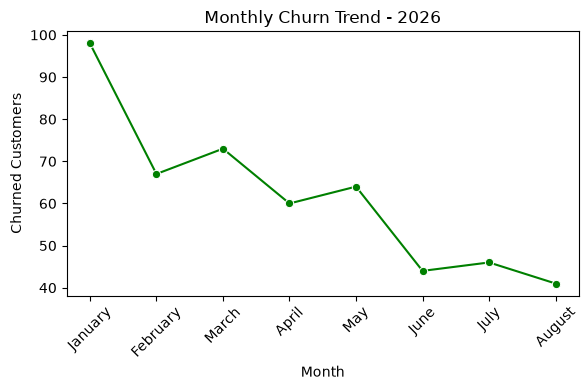

In [250]:
# Monthly Churn Trend for the Latest Year Only.
# Churn Trend for the Latest Year Only
churned = df_vis[df_vis['churn_flag']==1]
churned['year'] = churned['cancellation_date'].dt.year
churned['month'] = churned['cancellation_date'].dt.month_name()

# Find the latest year automatically
latest_year = churned['year'].max()
print("Latest year in data:", latest_year)

# Filter to only that year
latest_year_data = churned[churned['year'] == latest_year]

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_trend = latest_year_data['month'].value_counts().reindex(month_order)

plt.figure(figsize=(6,4))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='green')

plt.title(f'Monthly Churn Trend - {latest_year}')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly churn peaked in January (~120 customers) and declined steadily through the year, dropping to near-zero by December — suggesting either a seasonal cancellation pattern or a shrinking pool of active customers over time.

In [251]:
df['plan_type'].value_counts()

plan_type
Standard    34463
Premium     28414
Basic       27927
Unknown      2783
Name: count, dtype: int64

In [252]:
print(type(churn_by_plan_type))
print(churn_by_plan_type)

<class 'pandas.core.frame.DataFrame'>
  plan_type  Churn_%
0     Basic    19.84
1   Premium    19.77
2  Standard    19.98
3   Unknown    19.56


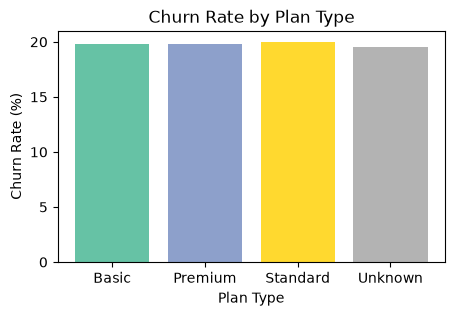

In [253]:
# Churn Rate by Plan type
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_plan_type)))

plt.figure(figsize=(5,3))
plt.bar(churn_by_plan_type['plan_type'], churn_by_plan_type['Churn_%'], color=colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

Churn rate stays about the same across all plan types — whether someone's on Basic, Standard, or Premium doesn't affect if they leave.

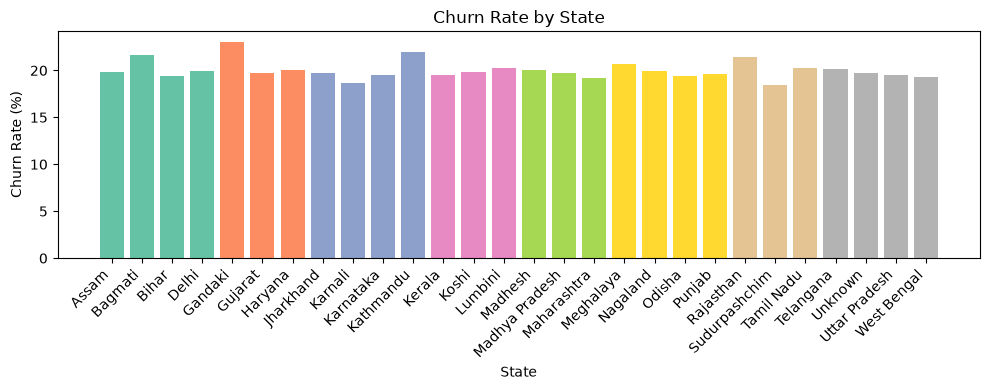

In [254]:
# Churn by States.
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_state)))

plt.figure(figsize=(10,4))
plt.bar(churn_by_state['state'], churn_by_state['Churn_%'], color=colors)

plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

Churn rate is fairly consistent across all states, with Gandaki slightly higher.

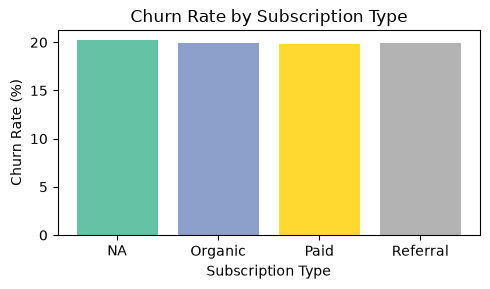

In [255]:
# Churn by Subscription Type.
# colors = ['skyblue','pink','plum','lightgreen']

colors = plt.cm.Set2(np.linspace(0,1,len(churn_by_subscription_type)))

plt.figure(figsize=(5,3))
plt.bar(churn_by_subscription_type['subscription_type'], churn_by_subscription_type['Churn_%'], color=colors)

plt.title('Churn Rate by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()


Churn rate stays about the same. No matter how the customer joined — through ads, search, or a referral. How they found us doesn't affect whether they stay or leave.

In [256]:
# Churn by contract type (Monthly vs Annual)
df_vis.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'churn_risk', 'customername', 'country', 'state',
       'gender', 'dob', 'age', 'complaint_date', 'escalations', 'csat_score',
       'comment', 'complaint_count', 'Total_Service_Days'],
      dtype='object')

In [257]:
df['contract_type'].isnull().sum()

np.int64(0)

In [258]:
df['contract_type'].value_counts()

contract_type
Annual     45819
Monthly    44114
Unknown     3654
Name: count, dtype: int64

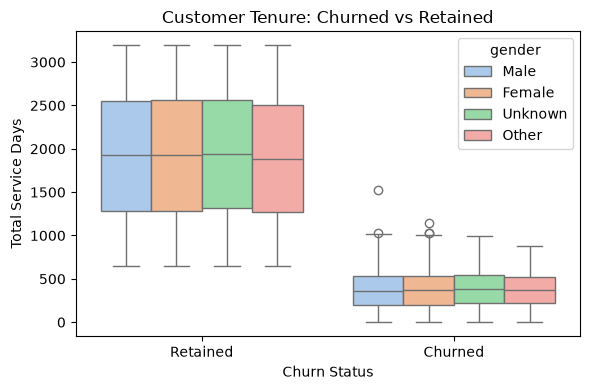

In [259]:
# Tenure: Churned vs Retained
plt.figure(figsize=(6,4))
sns.boxplot(data=df_vis, x='churn_flag', y='Total_Service_Days', hue='gender', palette='pastel')

plt.title('Customer Tenure: Churned vs Retained')
plt.xlabel('Churn Status')
plt.ylabel('Total Service Days')
plt.xticks([0,1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

Tenure is a strong churn signal — churned customers leave early (median ~1 year), while retained customers stay for years (median ~5 years).

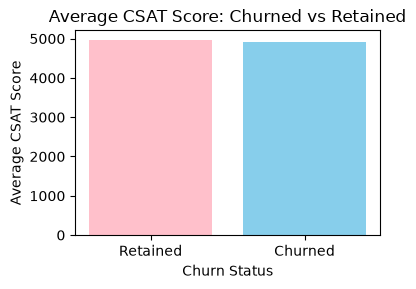

In [260]:
# CSAT Score: Churned vs Retained
plt.figure(figsize=(4,3))
plt.bar(['Retained','Churned'], avg_csat['Avg_CSAT_Score'].values, color=['pink','skyblue'])

plt.title('Average CSAT Score: Churned vs Retained')
plt.xlabel('Churn Status')
plt.ylabel('Average CSAT Score')
plt.tight_layout()
plt.show()

Churned and retained customers gave almost the same CSAT score on average — so satisfaction score alone doesn't explain why people leave.

**Loading Churn Cleaned Dataset to PostgreSQL**

In [262]:
# Export Cleaned Dataframe to csv file.
df.to_csv('D:\\VS Code\\Churn Analysis\\Complete project file\\Churn_clean_Dataset.csv',index= False)

In [263]:
df.to_sql('churn_dataset', engine2, if_exists="replace", index=False)

587